# Лабораторная работа №2  
## «Виртуальный датчик для контроля процесса обжига в печи»

В работе я считаю, что время в `target_train.csv` соответствует моменту получения лабораторного результата. Так как по условию результат приходит через 10–15 минут после отбора пробы, для синхронизации я сдвигаю лабораторный замер на 15 минут назад.

In [ ]:
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from scipy.stats import normaltest
from statsmodels.tools.tools import add_constant

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
RANDOM_STATE = 42

## 1. Загрузка данных

Сначала загружаю телеметрию и лабораторные замеры, проверяю структуру таблиц, период наблюдений, пропуски и частоту появления целевой переменной.

In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive'

DATA_PATH = os.path.join(BASE_DIR, 'data_train.csv')
TARGET_PATH = os.path.join(BASE_DIR, 'target_train.csv')

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Файл data_train.csv не найден по пути: {DATA_PATH}')

if not os.path.exists(TARGET_PATH):
    raise FileNotFoundError(f'Файл target_train.csv не найден по пути: {TARGET_PATH}')

raw_data = pd.read_csv(DATA_PATH, parse_dates=['datetime'])

target = (
    pd.read_csv(TARGET_PATH, parse_dates=['Дата'])
    .rename(columns={'Дата': 'datetime'})
)

telemetry_cols = [c for c in raw_data.columns if c != 'datetime']

display(raw_data.head())
display(target.head())

print('Размер телеметрии:', raw_data.shape)
print('Размер target:', target.shape)
print('Период телеметрии:', raw_data['datetime'].min(), '—', raw_data['datetime'].max())
print('Период target:', target['datetime'].min(), '—', target['datetime'].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


,datetime,target
0,2019-03-13 17:00:00,0.123711
1,2019-03-13 21:00:00,0.319588
2,2019-03-14 01:00:00,0.255155
3,2019-03-14 05:00:00,0.319588
4,2019-03-14 09:00:00,0.159794


Размер телеметрии: (319546, 17)
Размер target: (1773, 2)
Период телеметрии: 2019-03-01 00:01:00 — 2019-10-07 19:58:00
Период target: 2019-03-13 17:00:00 — 2019-10-07 21:00:00


In [ ]:
# Дубликаты временных меток агрегирую средним значением
duplicate_timestamps = raw_data['datetime'].duplicated().sum()
data = raw_data.sort_values('datetime').groupby('datetime', as_index=True).mean(numeric_only=True)
target = target.sort_values('datetime')
del raw_data

eda_summary = pd.DataFrame({
    'missing_share': data.isna().mean(),
    'mean': data.mean(),
    'std': data.std(),
    'min': data.min(),
    'max': data.max()
}).sort_values('missing_share', ascending=False)

target_intervals = target['datetime'].diff().dt.total_seconds().div(60)
print('Количество дубликатов datetime в телеметрии:', duplicate_timestamps)
print('Медианный интервал лабораторных замеров, минут:', target_intervals.median())
print('Средний интервал лабораторных замеров, минут:', target_intervals.mean())
display(eda_summary)
display(target['target'].describe())

Количество дубликатов datetime в телеметрии: 1548
Медианный интервал лабораторных замеров, минут: 120.0
Средний интервал лабораторных замеров, минут: 169.1647855530474


,missing_share,mean,std,min,max
telemetry_12,0.993406,0.510319,0.156012,0.012422,1.000000
telemetry_13,0.993406,0.530983,0.143269,0.100000,0.990000
telemetry_14,0.993406,0.443564,0.088670,0.102273,0.909091
telemetry_15,0.993406,0.473645,0.123467,0.000000,0.925150
telemetry_4,0.000418,0.762025,0.325680,0.000000,1.000000
telemetry_0,0.000053,0.609986,0.276336,0.003472,1.000000
telemetry_5,0.000053,0.695859,0.284229,0.000000,1.000000
telemetry_1,0.000050,0.379996,0.197836,0.000000,0.610826
telemetry_7,0.000050,0.522698,0.252907,0.020644,1.000000
telemetry_6,0.000050,0.594035,0.300441,0.000000,1.000000


,target
count,1773.000000
mean,0.254272
std,0.092208
min,0.000000
25%,0.175258
50%,0.247423
75%,0.314433
max,0.716495


## 2. EDA: визуальный анализ телеметрии и целевой переменной

На графиках смотрю общую динамику датчиков, пропуски, распределение целевой переменной и нерегулярность лабораторных замеров.

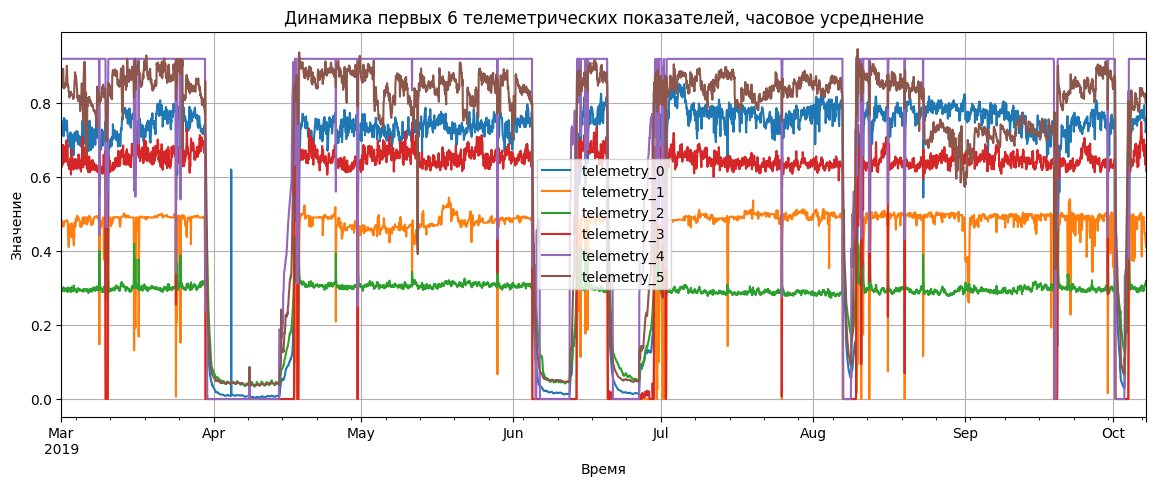

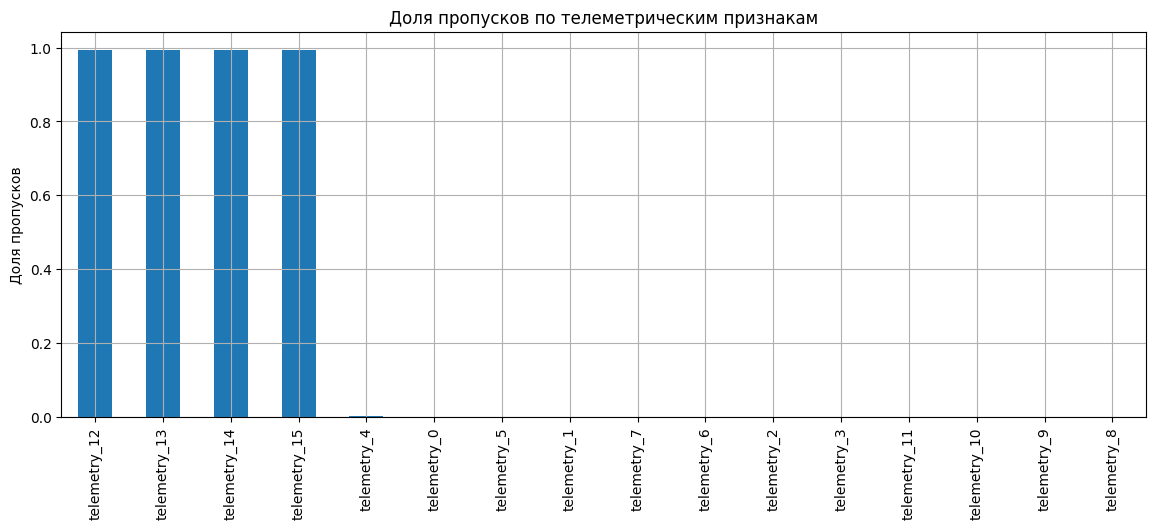

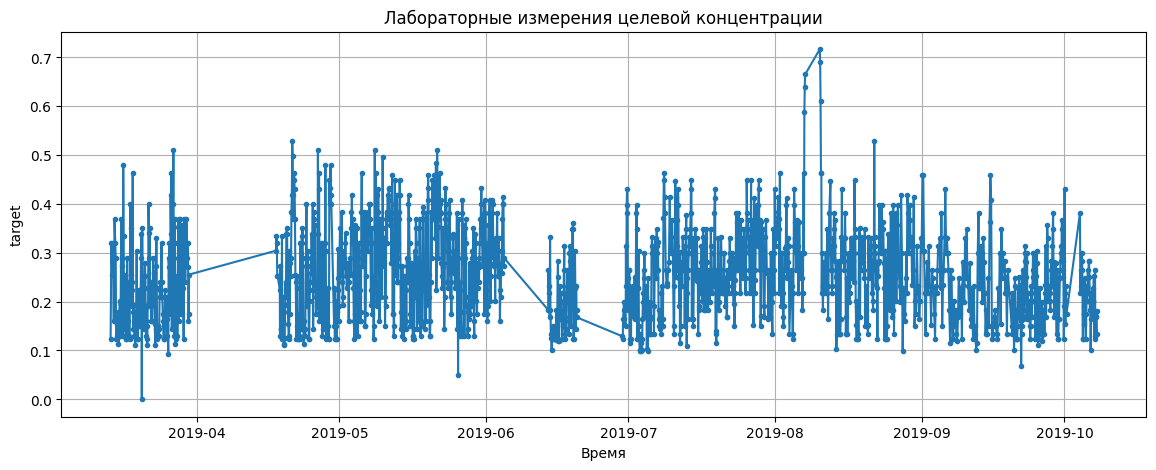

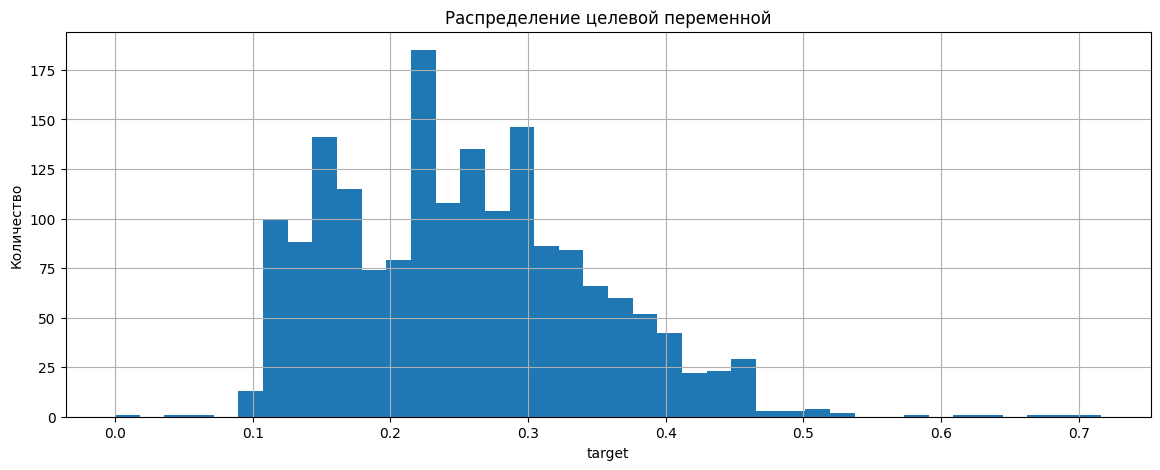

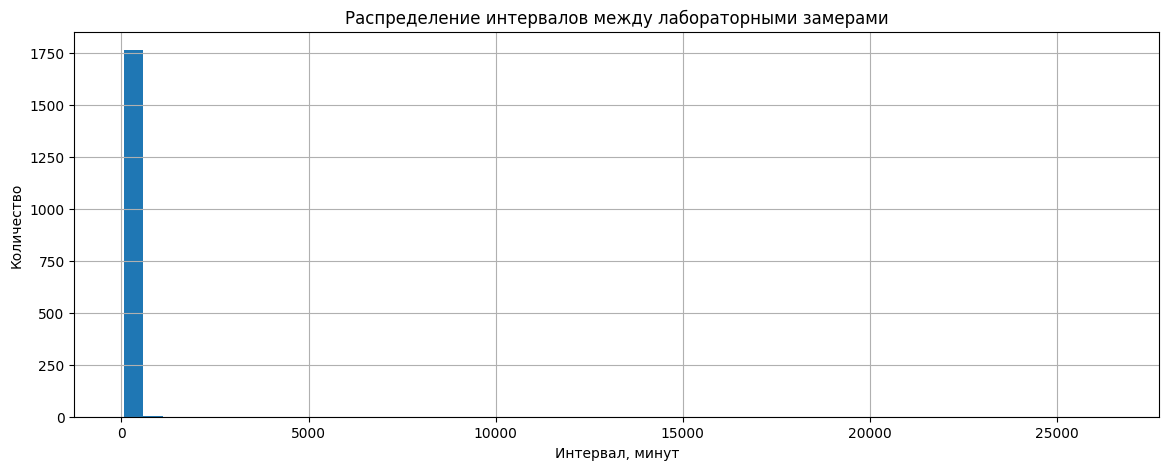

In [ ]:
# Для графиков используется часовое усреднение, чтобы не перегружать ноутбук сотнями тысяч минутных точек
data[telemetry_cols[:6]].resample('1H').mean().plot(title='Динамика первых 6 телеметрических показателей, часовое усреднение')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.show()

# Карта пропусков: доля пропусков по датчикам
eda_summary['missing_share'].plot(kind='bar', title='Доля пропусков по телеметрическим признакам')
plt.ylabel('Доля пропусков')
plt.show()

# Целевая переменная во времени
plt.plot(target['datetime'], target['target'], marker='.', linestyle='-')
plt.title('Лабораторные измерения целевой концентрации')
plt.xlabel('Время')
plt.ylabel('target')
plt.show()

# Распределение target
target['target'].hist(bins=40)
plt.title('Распределение целевой переменной')
plt.xlabel('target')
plt.ylabel('Количество')
plt.show()

# Интервалы между лабораторными измерениями
target_intervals.hist(bins=50)
plt.title('Распределение интервалов между лабораторными замерами')
plt.xlabel('Интервал, минут')
plt.ylabel('Количество')
plt.show()

### Вывод по EDA

1. Телеметрия имеет минутную частоту, но содержит пропуски и дубликаты временных меток, поэтому перед моделированием требуется привести ряд к регулярной минутной сетке.
2. Лабораторные измерения целевой концентрации нерегулярные и значительно более редкие, чем телеметрия, поэтому обычное построчное объединение таблиц не подходит.
3. Целевой показатель изменяется во времени не мгновенно, поэтому для прогноза нужно использовать не только текущие значения датчиков, но и лаги, скользящие статистики и признаки динамики.
4. Пропуски в телеметрии я обрабатываю временной интерполяцией, потому что для промышленного процесса соседние минутные измерения обычно физически связаны и плавны. Экстремальные выбросы ограничиваю квантилями 0.5% и 99.5%, чтобы снизить влияние аномальных скачков датчиков.

## 3. Синхронизация источников и анализ лаговых корреляций

Лабораторный результат приходит с задержкой. Поэтому время лабораторного значения сдвигаю на 15 минут назад и считаю его приближенным временем отбора пробы. Далее для каждого датчика проверяю корреляцию с целевой переменной на нескольких лагах.

In [ ]:
# Приведение телеметрии к регулярной минутной сетке
minute_data = data.asfreq('min')
missing_minutes_added = len(minute_data) - len(data)

# Интерполяция пропусков и ограничение выбросов
X_full = minute_data.interpolate(method='time', limit_direction='both').ffill().bfill()
low = X_full.quantile(0.005)
high = X_full.quantile(0.995)
X_clean = X_full.clip(lower=low, upper=high, axis=1)

# Сдвиг лабораторных замеров на 15 минут назад
target_sync = target.copy()
target_sync['sample_datetime'] = target_sync['datetime'] - pd.Timedelta(minutes=15)
target_sync = target_sync[target_sync['sample_datetime'].between(X_clean.index.min(), X_clean.index.max())]
target_sync = target_sync.set_index('sample_datetime')

print('Добавлено отсутствующих минут при регуляризации:', missing_minutes_added)
print('Число синхронизированных лабораторных замеров:', len(target_sync))

Добавлено отсутствующих минут при регуляризации: 0
Число синхронизированных лабораторных замеров: 1772


Ключевые признаки по лаговой корреляции: ['telemetry_15', 'telemetry_3', 'telemetry_0', 'telemetry_12', 'telemetry_13', 'telemetry_9']


,feature,lag_min,corr,abs_corr
92,telemetry_15,30,0.190112,0.190112
91,telemetry_15,15,0.189050,0.189050
90,telemetry_15,0,0.185973,0.185973
93,telemetry_15,60,0.182994,0.182994
19,telemetry_3,15,-0.180192,0.180192
0,telemetry_0,0,-0.176452,0.176452
1,telemetry_0,15,-0.170062,0.170062
2,telemetry_0,30,-0.163446,0.163446
74,telemetry_12,30,-0.151387,0.151387
73,telemetry_12,15,-0.151169,0.151169


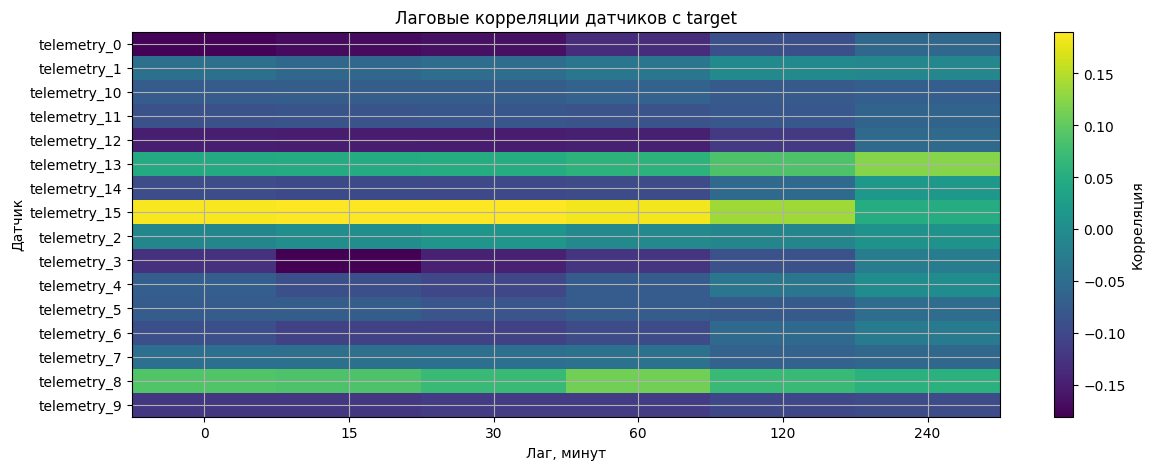

In [ ]:
lag_candidates = [0, 15, 30, 60, 120, 240]
lag_rows = []

for col in telemetry_cols:
    for lag in lag_candidates:
        shifted = X_clean[col].shift(lag).reindex(target_sync.index)
        tmp = pd.DataFrame({'x': shifted, 'y': target_sync['target']}).dropna()
        corr = tmp['x'].corr(tmp['y']) if len(tmp) > 30 and tmp['x'].std() > 0 else np.nan
        lag_rows.append({
            'feature': col,
            'lag_min': lag,
            'corr': corr,
            'abs_corr': abs(corr) if pd.notna(corr) else np.nan
        })

lag_corr = pd.DataFrame(lag_rows).sort_values('abs_corr', ascending=False)
key_features = lag_corr.dropna().drop_duplicates('feature').head(6)['feature'].tolist()

print('Ключевые признаки по лаговой корреляции:', key_features)
display(lag_corr.head(20))

pivot_corr = lag_corr.pivot(index='feature', columns='lag_min', values='corr')
plt.imshow(pivot_corr, aspect='auto')
plt.colorbar(label='Корреляция')
plt.xticks(range(len(pivot_corr.columns)), pivot_corr.columns)
plt.yticks(range(len(pivot_corr.index)), pivot_corr.index)
plt.title('Лаговые корреляции датчиков с target')
plt.xlabel('Лаг, минут')
plt.ylabel('Датчик')
plt.show()

### Вывод по синхронизации и лагам

1. Сдвиг target на 15 минут назад позволяет сопоставить лабораторный результат с состоянием печи в момент отбора пробы, а не в момент получения анализа.
2. Максимальные корреляции часто возникают не только при лаге 0, но и при лагах 15–240 минут.

## 4. Инжиниринг признаков временных рядов

Создаю признаки трех типов:
- лаговые значения датчиков;
- скользящие статистики за окна 30 и 120 минут;
- изменения показателей за 5 и 15 минут.

In [ ]:
features = pd.DataFrame(index=X_clean.index)

for col in key_features:
    base = X_clean[col]

    # Лаговые признаки
    for lag in [0, 15, 60, 120]:
        features[f'{col}_lag_{lag}'] = base.shift(lag)

    # Скользящие статистики
    for window in [30, 120]:
        roll = base.rolling(window, min_periods=max(5, window // 4))
        features[f'{col}_mean_{window}'] = roll.mean()
        features[f'{col}_std_{window}'] = roll.std()
        features[f'{col}_min_{window}'] = roll.min()
        features[f'{col}_max_{window}'] = roll.max()

    # Динамика изменения
    for diff_lag in [5, 15]:
        features[f'{col}_diff_{diff_lag}'] = base.diff(diff_lag)

features['hour'] = features.index.hour
features['dayofweek'] = features.index.dayofweek
features['month'] = features.index.month

model_df = features.reindex(target_sync.index).join(target_sync[['target']]).dropna()

print('Размер итогового датасета для моделирования:', model_df.shape)
display(model_df.head())

Размер итогового датасета для моделирования: (1772, 88)


,telemetry_15_lag_0,telemetry_15_lag_15,telemetry_15_lag_60,telemetry_15_lag_120,telemetry_15_mean_30,telemetry_15_std_30,telemetry_15_min_30,telemetry_15_max_30,telemetry_15_mean_120,telemetry_15_std_120,...,telemetry_9_mean_120,telemetry_9_std_120,telemetry_9_min_120,telemetry_9_max_120,telemetry_9_diff_5,telemetry_9_diff_15,hour,dayofweek,month,target
sample_datetime,,,,,,,,,,,,,,,,,,,,,
2019-03-13 16:45:00,0.214446,0.211826,0.201722,0.186003,0.211914,0.001538,0.209381,0.214446,0.200757,0.009402,...,0.703544,0.003453,0.697548,0.707282,0.000000,-0.000278,16,2,3,0.123711
2019-03-13 20:45:00,0.309132,0.315868,0.316617,0.265719,0.315644,0.003954,0.309132,0.322156,0.305851,0.018172,...,0.721166,0.008117,0.711454,0.734261,0.000556,0.001112,20,2,3,0.319588
2019-03-14 00:45:00,0.283308,0.277695,0.267590,0.272081,0.277882,0.003295,0.272455,0.283308,0.271426,0.004318,...,0.708759,0.002482,0.704501,0.711454,0.000000,0.000834,0,3,3,0.255155
2019-03-14 04:45:00,0.290793,0.301647,0.321856,0.315868,0.301285,0.006370,0.290793,0.311776,0.314805,0.008716,...,0.787142,0.005750,0.776536,0.795727,-0.000278,-0.003059,4,3,3,0.319588
2019-03-14 08:45:00,0.299401,0.284431,0.252246,0.243263,0.284930,0.008786,0.270459,0.299401,0.259637,0.016187,...,0.797691,0.032586,0.762908,0.861088,0.008622,0.019191,8,3,3,0.159794


In [ ]:
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train = train_df.drop(columns='target')
y_train = train_df['target']
X_test = test_df.drop(columns='target')
y_test = test_df['target']

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Период train:', X_train.index.min(), '—', X_train.index.max())
print('Период test:', X_test.index.min(), '—', X_test.index.max())

Train: (1417, 87) Test: (355, 87)
Период train: 2019-03-13 16:45:00 — 2019-08-23 22:45:00
Период test: 2019-08-24 00:45:00 — 2019-10-07 18:45:00


### Вывод по признакам

1. Лаговые признаки нужны, потому что процесс обжига инерционный: текущее качество зависит от прошлых режимов печи.
2. Скользящие средние, минимумы, максимумы и стандартные отклонения описывают устойчивость процесса и возможные колебания режима.
3. Производные признаки показывают направление и скорость изменения датчиков, что важно для раннего обнаружения отклонений.
4. Я не использую PCA как основной подход, потому что для производственной задачи важна интерпретируемость: оператору полезнее понимать вклад конкретных датчиков, а не абстрактных главных компонент.

## 5. Построение моделей

Я обучаю четыре подхода:

1. **Ridge-регрессия** — базовая интерпретируемая линейная модель с регуляризацией.
2. **ExtraTreesRegressor** — ансамбль деревьев, устойчивый к нелинейностям и взаимодействиям признаков.
3. **GradientBoostingRegressor** — бустинг, хорошо работает на табличных данных и способен учитывать сложные зависимости.
4. **SARIMAX только по target** — статистическая временная модель для сравнения, без телеметрии.

Модели, которые здесь хуже подходят:
- обычная линейная регрессия без лагов, потому что игнорирует инерционность процесса;
- случайное перемешивание train/test, потому что даст утечку будущего;
- чистые классификационные модели, потому что target является непрерывной концентрацией;
- очень сложные LSTM/Transformer без дополнительного объема данных и отдельного теста, потому что лабораторных измерений всего около нескольких тысяч, и риск переобучения высокий.

In [ ]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE_%': np.nanmean(np.abs((y_true - y_pred) / np.where(np.abs(y_true) < 1e-8, np.nan, y_true))) * 100,
        'WAPE_%': np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        'R2': r2_score(y_true, y_pred),
        'Direction_accuracy_%': np.mean(np.sign(dy_true) == np.sign(dy_pred)) * 100
    }

models = {
    'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=60,
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

results = []
predictions = {}
fitted_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fit_time = time.time() - start

    predictions[name] = pred
    fitted_models[name] = model
    row = {'model': name, **calculate_metrics(y_test, pred), 'fit_time_sec': fit_time}
    results.append(row)

# SARIMAX как статистическая базовая модель только по истории target
try:
    start = time.time()
    sarimax_model = SARIMAX(
        y_train,
        order=(1, 0, 1),
        seasonal_order=(0, 0, 0, 0),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_result = sarimax_model.fit(disp=False, maxiter=20)
    sarimax_pred = np.asarray(sarimax_result.forecast(steps=len(y_test)))
    predictions['SARIMAX_target_only'] = sarimax_pred

    results.append({
        'model': 'SARIMAX_target_only',
        **calculate_metrics(y_test, sarimax_pred),
        'AIC': sarimax_result.aic,
        'BIC': sarimax_result.bic,
        'fit_time_sec': time.time() - start
    })
except Exception as e:
    print('SARIMAX не удалось обучить:', repr(e))

metrics_df = pd.DataFrame(results)

# Для ML-моделей AIC/BIC не являются стандартными критериями, поэтому считаю приближенную Гауссовскую оценку по RSS
n = len(y_test)
for idx, row in metrics_df.iterrows():
    if pd.isna(row.get('AIC', np.nan)):
        pred = predictions[row['model']]
        rss = float(np.sum((y_test - pred) ** 2))
        k = min(X_train.shape[1] + 1, n - 1) if row['model'] == 'Ridge' else 20
        metrics_df.loc[idx, 'AIC_approx'] = n * np.log(rss / n) + 2 * k
        metrics_df.loc[idx, 'BIC_approx'] = n * np.log(rss / n) + np.log(n) * k

metrics_df = metrics_df.sort_values('RMSE')
display(metrics_df)

,model,MAE,RMSE,MAPE_%,WAPE_%,R2,Direction_accuracy_%,fit_time_sec,AIC,BIC,AIC_approx,BIC_approx
3,SARIMAX_target_only,0.070330,0.084243,39.906443,31.137700,-0.215155,12.994350,0.720830,-3194.788438,-3173.768899,NaN,NaN
1,ExtraTrees,0.072556,0.089096,41.568621,32.123432,-0.359182,50.564972,0.566433,NaN,NaN,-1676.809366,-1599.367011
2,GradientBoosting,0.075773,0.092785,43.322349,33.547666,-0.474066,52.542373,6.151615,NaN,NaN,-1648.004204,-1570.561848
0,Ridge,0.085252,0.103822,49.024084,37.744082,-0.845625,54.519774,0.037024,NaN,NaN,-1432.202572,-1091.456207


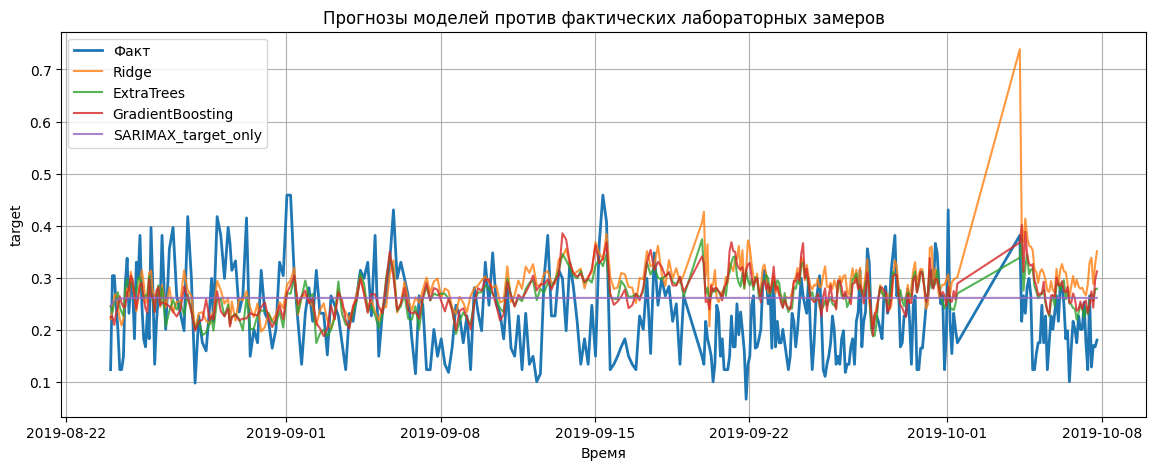

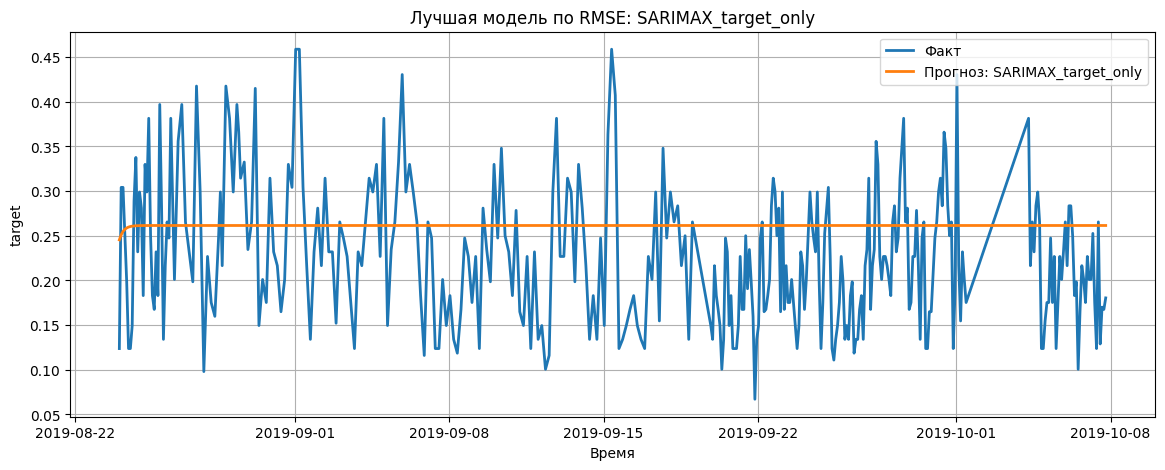

In [ ]:
# Визуализация прогнозов против фактических лабораторных замеров
plt.plot(y_test.index, y_test.values, label='Факт', linewidth=2)
for name, pred in predictions.items():
    plt.plot(y_test.index, pred, label=name, alpha=0.8)
plt.title('Прогнозы моделей против фактических лабораторных замеров')
plt.xlabel('Время')
plt.ylabel('target')
plt.legend()
plt.show()

# Отдельно лучшая модель
best_model_name = metrics_df.iloc[0]['model']
plt.plot(y_test.index, y_test.values, label='Факт', linewidth=2)
plt.plot(y_test.index, predictions[best_model_name], label=f'Прогноз: {best_model_name}', linewidth=2)
plt.title(f'Лучшая модель по RMSE: {best_model_name}')
plt.xlabel('Время')
plt.ylabel('target')
plt.legend()
plt.show()

### Вывод по моделям

1. В качестве основной бизнес-модели лучше рассматривать не только минимальный RMSE, но и способность предсказывать направление изменения target.
2. Статистическая SARIMAX-модель полезна как базовая линия, но она не использует телеметрию и поэтому хуже подходит на роль полноценного виртуального датчика.
3. Деревянные ансамбли лучше соответствуют физике процесса, потому что могут учитывать нелинейные зависимости между датчиками, лагами и скользящими статистиками.
4. Линейная Ridge-модель нужна как интерпретируемый baseline: если сложные модели выигрывают незначительно, простая модель может быть предпочтительнее для внедрения.

## 6. Анализ остатков и важность признаков

Для лучшей модели проверяю остатки: среднее, нормальность, автокорреляцию и гетероскедастичность. Также оцениваю важность признаков.

In [ ]:
best_model_name = metrics_df.iloc[0]['model']
best_pred = np.asarray(predictions[best_model_name])
residuals = np.asarray(y_test) - best_pred

residual_diagnostics = {
    'best_model': best_model_name,
    'residual_mean': residuals.mean(),
    'residual_std': residuals.std(),
    'normaltest_pvalue': normaltest(residuals).pvalue if len(residuals) >= 8 else np.nan,
    'ljung_box_pvalue_lag10': acorr_ljungbox(
        residuals,
        lags=[min(10, len(residuals) // 3)],
        return_df=True
    )['lb_pvalue'].iloc[0]
}

try:
    residual_diagnostics['breusch_pagan_pvalue'] = het_breuschpagan(
        residuals,
        add_constant(best_pred.reshape(-1, 1))
    )[1]
except Exception as e:
    residual_diagnostics['breusch_pagan_error'] = repr(e)

residual_diagnostics

{'best_model': 'SARIMAX_target_only',
 'residual_mean': np.float64(-0.03547412645908986),
 'residual_std': np.float64(0.07641011819303763),
 'normaltest_pvalue': np.float64(3.620469919073768e-05),
 'ljung_box_pvalue_lag10': np.float64(5.857483949011426e-17),
 'breusch_pagan_pvalue': np.float64(0.8049082740911238)}

,residuals
count,355.000000
mean,-0.035474
std,0.076518
min,-0.194459
25%,-0.093943
50%,-0.034665
75%,0.010438
max,0.197294


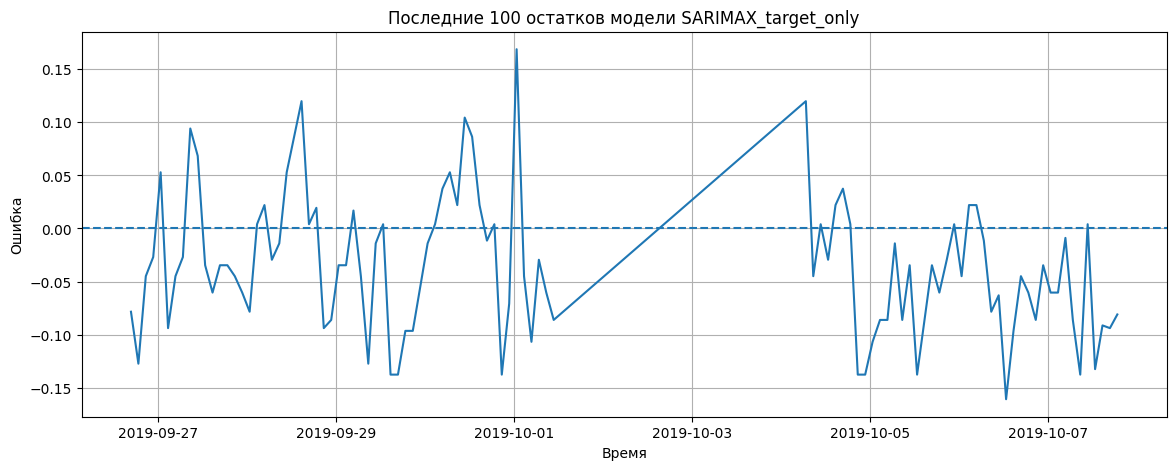

In [ ]:
# Табличная сводка остатко
residual_summary = pd.Series(residuals).describe().to_frame('residuals')
display(residual_summary)

plt.plot(y_test.index[-100:], residuals[-100:])
plt.axhline(0, linestyle='--')
plt.title(f'Последние 100 остатков модели {best_model_name}')
plt.xlabel('Время')
plt.ylabel('Ошибка')
plt.show()

In [ ]:
# Важность признаков
# Для деревьев беру встроенную важность, для Ridge — абсолютные коэффициенты после стандартизации
if best_model_name == 'Ridge':
    coefs = fitted_models[best_model_name].named_steps['ridge'].coef_
    importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': np.abs(coefs)})
elif best_model_name in fitted_models and hasattr(fitted_models[best_model_name], 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': fitted_models[best_model_name].feature_importances_
    })
else:
    # Если лучшая модель SARIMAX, важность телеметрии для нее недоступна, поэтому интерпретирую лучшую ML-модель по RMSE
    ml_metrics = metrics_df[metrics_df['model'].isin(fitted_models.keys())].sort_values('RMSE')
    ml_best_name = ml_metrics.iloc[0]['model']
    model_for_importance = fitted_models[ml_best_name]
    if hasattr(model_for_importance, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': X_test.columns,
            'importance': model_for_importance.feature_importances_
        })
    else:
        coefs = model_for_importance.named_steps['ridge'].coef_
        importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': np.abs(coefs)})

importance_df = importance_df.sort_values('importance', ascending=False).head(20)
display(importance_df)

,feature,importance
86,month,0.086289
35,telemetry_0_max_30,0.039272
29,telemetry_0_lag_15,0.037440
32,telemetry_0_mean_30,0.036617
28,telemetry_0_lag_0,0.029840
34,telemetry_0_min_30,0.026844
39,telemetry_0_max_120,0.023697
7,telemetry_15_max_30,0.023402
30,telemetry_0_lag_60,0.021395
36,telemetry_0_mean_120,0.020601


### Вывод по качеству и остаткам

1. Метрики MAE/RMSE показывают абсолютную ошибку прогноза, а WAPE удобен для бизнес-интерпретации, потому что показывает ошибку относительно суммарного уровня target.
2. Direction accuracy показывает, насколько модель улавливает направление изменения концентрации. Для оператора это важно: иногда направление ухудшения процесса важнее точного численного значения.
3. Остатки не являются полностью идеальными: в них может сохраняться автокорреляция. Это означает, что часть динамики процесса еще не объяснена признаками.
4. Важные признаки в основном связаны с лагами и скользящими статистиками выбранных датчиков. Это подтверждает, что качество продукта зависит от предыдущих режимов печи, а не только от текущего состояния.

## 7. Финальная интерпретация и рекомендации

По результатам работы я построил полный пайплайн виртуального датчика:

1. Телеметрия приведена к регулярной минутной сетке, пропуски заполнены временной интерполяцией, выбросы ограничены квантилями.
2. Лабораторные замеры синхронизированы с телеметрией через сдвиг на 15 минут назад, что соответствует задержке лабораторного анализа.
3. Для учета динамики процесса добавлены лаги, скользящие статистики и признаки изменения датчиков.
4. Обучены несколько моделей: линейная, ансамблевые ML-модели и статистическая SARIMAX-модель.
5. Модели сравнены по MAE, RMSE, MAPE, WAPE, directional accuracy, AIC/BIC или приближенным AIC/BIC, а также по времени обучения.

**Предпочтительная модель для внедрения:** ансамблевая ML-модель с лучшим балансом RMSE/WAPE и directional accuracy среди моделей, использующих телеметрию. Даже если SARIMAX показывает конкурентный RMSE, она не использует показания датчиков печи, поэтому не является полноценным виртуальным датчиком производственного процесса.

**Что можно улучшить дальше:**
- подобрать задержку не фиксированно 15 минут, а через grid search по 10–15 минутам;
- добавить больше технологических лагов и доменные признаки;
- провести настройку гиперпараметров через TimeSeriesSplit;

In [ ]:
os.makedirs('outputs', exist_ok=True)
metrics_df.to_csv('outputs/model_metrics.csv', index=False)
lag_corr.to_csv('outputs/lag_correlations.csv', index=False)
importance_df.to_csv('outputs/feature_importance.csv', index=False)

prediction_df = pd.DataFrame({'datetime': y_test.index, 'actual': y_test.values})
for name, pred in predictions.items():
    prediction_df[name] = pred
prediction_df.to_csv('outputs/predictions.csv', index=False)

print('Файлы сохранены в папку outputs/')

Файлы сохранены в папку outputs/
